# Quadratic Equation Workflow — LangGraph (Conditional Routing)

A simple workflow to understand the **Routing / Conditional Edges**
pattern in LangGraph: based on a decision, the flow branches to a
different node.

**What it does:**

- Takes THREE things as INPUT: the coefficients `a`, `b`, `c` of a
  quadratic equation `ax² + bx + c = 0`.
- CALCULATES the discriminant `D = b² - 4ac`.
- Based on the discriminant's value, ROUTES to one of three paths:
  - `D > 0` → Two distinct real roots.
  - `D == 0` → One repeated real root.
  - `D < 0` → Two complex (imaginary) roots.
- Returns the calculated root(s) as the OUTPUT.

**How it's built:**

- The whole workflow is represented as a **GRAPH** — one node
  calculates the discriminant, then a CONDITIONAL EDGE decides
  which of the three root-calculating nodes runs next.
- It has a **STATE** — a shared dictionary that holds `a`, `b`, `c`,
  the `discriminant`, and the final `result`. Each node reads what
  it needs from the state and writes its result back into it.


In [1]:
from typing import TypedDict, Literal


class QuadState(TypedDict):
    a: int
    b: int
    c: int
    equation: str
    discriminant: float
    result: str

In [2]:
def show_equation(state: QuadState) -> QuadState:
    a = state["a"]
    b = state["b"]
    c = state["c"]

    equation = f"{a}x^2 + {b}x + {c} = 0"

    return {"equation": equation}

In [ ]:
def calculate_discriminant(state: QuadState) -> QuadState:
    a = state["a"]
    b = state["b"]
    c = state["c"]

    discriminant = (b**2) - (4 * a * c)

    return {"discriminant": discriminant}

In [ ]:
def real_roots(state: QuadState) -> QuadState:
    a = state["a"]
    b = state["b"]
    discriminant = state["discriminant"]

    root1 = (-b + discriminant**0.5) / (2 * a)
    root2 = (-b - discriminant**0.5) / (2 * a)

    result = f"The roots are real and distinct: {root1:.2f} and {root2:.2f}"

    return {"result": result}

In [5]:
def repeated_root(state: QuadState) -> QuadState:
    a = state["a"]
    b = state["b"]

    root = -b / (2 * a)

    result = f"The roots are real and equal: {root:.2f}"

    return {"result": result}

In [6]:
def no_real_roots(state: QuadState) -> QuadState:
    a = state["a"]
    b = state["b"]
    discriminant = state["discriminant"]

    real_part = -b / (2 * a)
    imaginary_part = abs(discriminant) ** 0.5 / (2 * a)

    result = (
        f"No real roots (roots are complex): "
        f"{real_part:.2f} + {imaginary_part:.2f}i and "
        f"{real_part:.2f} - {imaginary_part:.2f}i"
    )

    return {"result": result}

In [ ]:
def check_condition(
    state: QuadState,
) -> Literal["real_roots", "repeated_root", "no_real_roots"]:
    discriminant = state["discriminant"]

    if discriminant > 0:
        return "real_roots"
    elif discriminant == 0:
        return "repeated_root"
    else:
        return "no_real_roots"

In [8]:
from langgraph.graph import StateGraph, START, END

# define the graph
graph = StateGraph(QuadState)

# define nodes
graph.add_node("show_equation", show_equation)
graph.add_node("calculate_discriminant", calculate_discriminant)
graph.add_node("real_roots", real_roots)
graph.add_node("repeated_root", repeated_root)
graph.add_node("no_real_roots", no_real_roots)

# add edges
graph.add_edge(START, "show_equation")
graph.add_edge("show_equation", "calculate_discriminant")

# conditional edge — routes based on check_condition's return value
graph.add_conditional_edges("calculate_discriminant", check_condition)

graph.add_edge("real_roots", END)
graph.add_edge("repeated_root", END)
graph.add_edge("no_real_roots", END)

# compile graph
workflow = graph.compile()

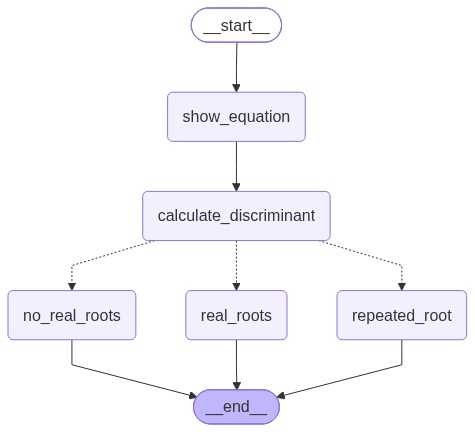

In [9]:
# print/visualize the graph
from IPython.display import Image, display

display(Image(workflow.get_graph().draw_mermaid_png()))

In [10]:
# execute the graph
initial_state = {"a": 2, "b": -7, "c": 3}
print(initial_state)

final_state = workflow.invoke(initial_state)

print("Equation:", final_state["equation"])
print("Discriminant:", final_state["discriminant"])
print("Result:", final_state["result"])

{'a': 2, 'b': -7, 'c': 3}
Equation: 2x^2 + -7x + 3 = 0
Discriminant: 25
Result: The roots are real and distinct: 3.00 and 0.50
